In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, date


print("Libraries imported successfully")
TODAY = date.today()
print(f'Setup complete.\nToday\'s date: {TODAY}')

Libraries imported successfully
Setup complete.
Today's date: 2026-03-17


In [18]:
path = '06_drug_inventory.csv'

In [19]:
def load_stock(path):
    # Load the CSV file
    df = pd.read_csv(path)  # replace with your actual file name

    # Handle missing values: drop rows with any missing data
    df.dropna(inplace=True)

    # Sort data by supplier
    # df = df.sort_values(by='supplier')

    return df

drug_df = load_stock(path)
display(drug_df.head(30))

,drug_id,drug_name,category,quantity_in_stock,reorder_level,unit_price_usd,expiry_date,form,supplier
0,DRG001,Paracetamol,Analgesic,113,98,25.87,2025-11-14,Tablet,Supplier D
1,DRG002,Amoxicillin,Antibiotic,202,53,46.25,2027-04-14,Capsule,Supplier B
2,DRG003,Artemether,Antimalarial,165,192,16.61,2025-05-03,Tablet,Supplier C
3,DRG004,Metformin,Antidiabetic,449,105,15.13,2025-08-06,Tablet,Supplier A
4,DRG005,Lisinopril,Antihypertensive,282,67,30.49,2024-11-20,Tablet,Supplier C
5,DRG006,Omeprazole,Antacid,336,65,26.09,2026-06-20,Capsule,Supplier D
6,DRG007,Ibuprofen,NSAID,376,77,26.29,2025-12-26,Tablet,Supplier B
7,DRG008,Ciprofloxacin,Antibiotic,172,140,7.45,2026-05-03,Tablet,Supplier B
8,DRG009,Diazepam,Sedative,312,120,41.15,2027-06-16,Tablet,Supplier A
9,DRG010,Folic Acid,Supplement,137,82,20.95,2026-08-31,Tablet,Supplier A


# **Drug Class**

In [20]:
class Drug:
    def __init__(self, path):
        # Store the dataframe as an instance attribute
        self.path = path
        self.drugs = load_stock(path)
        # Convert expiry_date to datetime for proper comparisons
        self.drugs['expiry_date'] = pd.to_datetime(self.drugs['expiry_date'])
        # You can also call a summary method here if needed
        # self.summary = self.drug_summary()   # if you define drug_summary
        self.total_drugs = len(self.drugs)

    def price_summary(self):
        """Return most expensive and cheapest drug details."""
        df = self.drugs
        most_expensive = df.loc[df['unit_price_usd'].idxmax()]
        cheapest = df.loc[df['unit_price_usd'].idxmin()]
        return {
            "most_expensive": most_expensive.to_dict(),  # convert Series to dict
            "cheapest": cheapest.to_dict()
        }

    def supplier_summary(self):
        df = self.drugs
        supplier_dict = {}
        for supplier, group in df.groupby('supplier'):
            supplier_dict[supplier] = {
                'list_of_drugs': group['drug_name'].tolist(),
                'total_number': int(group['quantity_in_stock'].sum())
            }
        counts = {
            'form': df['form'].value_counts().to_dict(),
            'category': df['category'].value_counts().to_dict(),
            'supplier': df['supplier'].value_counts().to_dict()
        }
        return {'supplier_details': supplier_dict, 'counts': counts}

    def total_inventory_value(self, by_supplier=False):
        """
        Calculate the total inventory value (quantity * unit_price).

        Args:
            by_supplier (bool): If True, return a dictionary with values per supplier.

        Returns:
            float or dict: Total value (float) if by_supplier=False,
                        otherwise dict {supplier: total_value}.
        """
        df = self.drugs
        df['total_value'] = df['quantity_in_stock'] * df['unit_price_usd']

        if by_supplier:
            return df.groupby('supplier')['total_value'].sum().to_dict()
        else:
            return df['total_value'].sum()

    def description(self):
        """Return a string describing the Drug class and its data."""
        return (
            f"Drug Class: Manages pharmaceutical drug data.\n"
            f"Loaded {self.total_drugs} drug records.\n"
            f"Available methods: price_summary(), supplier_summary().\n"
            f"Use this class to analyze drug prices and supplier information."
        )

print('Drug class created !')

Drug class created !


# **Class Inventory**

In [21]:
class Inventory:

    def __init__(self, df):
        # Store the dataframe as an instance attribute so all methods can access it
        self.df = df.copy()  # copy to avoid modifying original
        # Ensure expiry_date is datetime for consistent comparisons
        self.df['expiry_date'] = pd.to_datetime(self.df['expiry_date'])
        # Store total items as an attribute (optional)
        self.total_items = self.df['quantity_in_stock'].sum()
        self.total_drugs = len(self.df)



    def get_low_stock(self):

        df = self.df
        return df[(df['quantity_in_stock'] <= df['reorder_level']) &
                  (df['reorder_level'] - df['quantity_in_stock'] <= 15)]

    def get_re_stock(self):

        df = self.df
        return df[df['quantity_in_stock'] <= df['reorder_level'] + 20]

    def stock_summary(self):
        """
        Return a dictionary with details of most/least stock and newest/oldest expiry.
        """
        df = self.df
        most_stock = df.loc[df['quantity_in_stock'].idxmax()].to_dict()
        least_stock = df.loc[df['quantity_in_stock'].idxmin()].to_dict()
        latest_expiry = df.loc[df['expiry_date'].idxmax()].to_dict()
        oldest_expiry = df.loc[df['expiry_date'].idxmin()].to_dict()

        return {
            "most_stock": most_stock,
            "least_stock": least_stock,
            "latest_expiry": latest_expiry,
            "oldest_expiry": oldest_expiry
        }

    def check_expiry(self):

        today = pd.Timestamp.now().normalize()
        expired = self.df[self.df["expiry_date"] < today]
        return expired

    def near_expiry(self, days=30):

        today = pd.Timestamp.now().normalize()
        threshold = today + pd.Timedelta(days=days)
        near_exp = self.df[(self.df['expiry_date'] > today) &
                        (self.df['expiry_date'] <= threshold)]
        return near_exp

    def expiry_loss_forecast(self, days=90):

        expiring = self.near_expiry(days)

        if expiring.empty:
            return 0.0
        # Compute total value (quantity * unit price)
        total_value = (expiring['quantity_in_stock'] * expiring['unit_price_usd']).sum()
        return total_value

    def description(self):
        return (
            f"Inventory Class: Manages drug inventory operations.\n"
            f"Currently tracking {self.total_drugs} drug types with {self.total_items} total items in stock.\n"
            f"Available methods: check_expiry(), get_low_stock(), get_re_stock(), stock_summary(), near_expiry(), description()."
        )

    def restock_report(self, filename="restock_report.txt"):

        lines = []
        lines.append(f"Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
        lines.append("")

        # Basic counts (from instance attributes)
        lines.append(f"Total drug types: {self.total_drugs}")
        lines.append(f"Total items in stock: {self.total_items}")
        lines.append("")

        # Total inventory value (compute directly)
        total_value = (self.df['quantity_in_stock'] * self.df['unit_price_usd']).sum()
        lines.append(f"Total inventory value: ${total_value:,.2f}")
        lines.append("")

        # Expired drugs (using check_expiry)
        expired = self.check_expiry()
        lines.append(f"Expired drugs: {len(expired)}")
        if not expired.empty:
            lines.append("  " + ", ".join(expired['drug_name'].tolist()))
        lines.append("")

        # Low stock (within 15 below reorder) using get_low_stock
        low_stock = self.get_low_stock()
        lines.append(f"Low stock drugs (within 15 below reorder): {len(low_stock)}")
        if not low_stock.empty:
            for _, row in low_stock.iterrows():
                lines.append(f"  {row['drug_name']}: {row['quantity_in_stock']} (reorder at {row['reorder_level']})")
        lines.append("")

        # Restock soon (≤ reorder + 20) using get_re_stock
        restock = self.get_re_stock()
        lines.append(f"Drugs needing restock soon (≤ reorder+20): {len(restock)}")
        if not restock.empty:
            for _, row in restock.iterrows():
                lines.append(f"  {row['drug_name']}: {row['quantity_in_stock']} (reorder at {row['reorder_level']})")
        lines.append("")

        # Expiry loss forecasts using expiry_loss_forecast
        lines.append("Expiry loss forecast (value of drugs expiring within...):")
        for days in [30, 60, 90]:
            loss = self.expiry_loss_forecast(days)
            lines.append(f"  Next {days} days: ${loss:,.2f}")
        lines.append("")

        # Top 5 most stocked drugs
        top_stock = self.df.nlargest(5, 'quantity_in_stock')[['drug_name', 'quantity_in_stock']]
        lines.append("Top 5 most stocked drugs:")
        for _, row in top_stock.iterrows():
            lines.append(f"  {row['drug_name']}: {row['quantity_in_stock']} units")
        lines.append("")

        # Top 5 most valuable drugs (by current stock value)
        # Add temporary column without altering original df
        df_temp = self.df.copy()
        df_temp['stock_value'] = df_temp['quantity_in_stock'] * df_temp['unit_price_usd']
        top_value = df_temp.nlargest(5, 'stock_value')[['drug_name', 'stock_value']]
        lines.append("Top 5 most valuable drugs (by current stock value):")
        for _, row in top_value.iterrows():
            lines.append(f"  {row['drug_name']}: ${row['stock_value']:,.2f}")
        lines.append("")

        lines.append("=" * 60)

        # Write to file with UTF‑8 encoding
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("\n".join(lines))

        # Print to console
        # print(f"\nRestock report saved to {filename}")
        return "\n".join(lines)


    def expiry_report(self, days=90, filename="expiry_report.txt"):

        lines = []
        lines.append(f"Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
        lines.append(f"Forecast window: {days} days")
        lines.append("")

        # ---------- Expired drugs ----------
        expired = self.check_expiry()
        lines.append("EXPIRED DRUGS")
        lines.append("-" * 40)
        if expired.empty:
            lines.append("  No expired drugs.")
        else:
            lines.append(f"  Total expired items: {len(expired)}")
            lines.append("  List:")
            for _, row in expired.iterrows():
                lines.append(f"    {row['drug_name']} (expired on {row['expiry_date'].date()}) – {row['quantity_in_stock']} units")
        lines.append("")

        # ---------- Near‑expiry drugs (within `days`) ----------
        near = self.near_expiry(days)
        lines.append(f"DRUGS EXPIRING WITHIN {days} DAYS")
        lines.append("-" * 40)
        if near.empty:
            lines.append(f"  No drugs expire within the next {days} days.")
        else:
            lines.append(f"  Total items: {len(near)}")
            lines.append("  List by expiry date:")
            # Sort by expiry date for clarity
            near_sorted = near.sort_values('expiry_date')
            for _, row in near_sorted.iterrows():
                lines.append(f"    {row['drug_name']} – expires {row['expiry_date'].date()} – {row['quantity_in_stock']} units")
        lines.append("")

        # ---------- Loss forecast ----------
        loss = self.expiry_loss_forecast(days)
        lines.append("LOSS FORECAST")
        lines.append("-" * 40)
        lines.append(f"  Total value of drugs expiring within {days} days: ${loss:,.2f}")
        lines.append("")

        # ---------- Breakdown by category (optional) ----------
        if not near.empty:
            # Add temporary value column
            near_with_value = near.copy()
            near_with_value['value'] = near_with_value['quantity_in_stock'] * near_with_value['unit_price_usd']

            # By category
            cat_sum = near_with_value.groupby('category')['value'].sum().sort_values(ascending=False)
            lines.append("EXPIRING VALUE BY CATEGORY")
            lines.append("-" * 40)
            for category, val in cat_sum.items():
                lines.append(f"  {category}: ${val:,.2f}")
            lines.append("")

            # Top 5 most valuable expiring drugs
            top_value = near_with_value.nlargest(5, 'value')[['drug_name', 'value']]
            lines.append("TOP 5 MOST VALUABLE EXPIRING DRUGS")
            lines.append("-" * 40)
            for _, row in top_value.iterrows():
                lines.append(f"  {row['drug_name']}: ${row['value']:,.2f}")
            lines.append("")

        # Write to file with UTF‑8 encoding
        with open(filename, 'w', encoding='utf-8') as f:
            f.write("\n".join(lines))

        #DRUG INVENTORY RESTOCK REPORT
       # print(f"\nExpiry report saved to {filename}")
        return "\n".join(lines)

print('Inventory class created !')

Inventory class created !


In [22]:

def generate_restock_report(Inventory):
    return Inventory.restock_report()

print('generate_restock_report function created')

generate_restock_report function created


In [23]:
def generate_expiry_report(Inventory):
    return Inventory.expiry_report()

print('generate_expiry_report function created')

generate_expiry_report function created


### **Chart Functions**

In [29]:


def plot_stock_levels(df, top_n=10):
    """
    Generates a bar chart of the top N drugs by quantity in stock.

    Args:
        df (pd.DataFrame): The drug inventory DataFrame.
        top_n (int): The number of top drugs to display.
    """
    plt.figure(figsize=(12, 6))
    top_drugs = df.nlargest(top_n, 'quantity_in_stock').sort_values('quantity_in_stock', ascending=False)
    sns.barplot(x='drug_name', y='quantity_in_stock', data=top_drugs, hue='drug_name', legend=False, palette='viridis')
    plt.title(f'Top {top_n} Drugs by Quantity in Stock')
    plt.xlabel('Drug Name')
    plt.ylabel('Quantity in Stock')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_drug_categories(df):
    """
    Generates a pie chart showing the distribution of drug categories.

    Args:
        df (pd.DataFrame): The drug inventory DataFrame.
    """
    plt.figure(figsize=(10, 10))
    category_counts = df['category'].value_counts()
    plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.title('Distribution of Drug Categories')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.tight_layout()
    plt.show()

def plot_stock_by_expiry_timeline(df):
    """
    Generates a line chart showing the total quantity in stock grouped by expiry month/year.
    This provides a timeline view of expiring stock, addressing the 'stock changes over time'
    request given the available data.

    Args:
        df (pd.DataFrame): The drug inventory DataFrame.
    """
    # Ensure expiry_date is in datetime format
    df['expiry_date'] = pd.to_datetime(df['expiry_date'])

    # Group by expiry month/year and sum the quantities
    df['expiry_month_year'] = df['expiry_date'].dt.to_period('M')
    monthly_expiring_stock = df.groupby('expiry_month_year')['quantity_in_stock'].sum().reset_index()

    # Convert Period back to Timestamp for better plotting on x-axis
    monthly_expiring_stock['expiry_month_year'] = monthly_expiring_stock['expiry_month_year'].dt.to_timestamp()

    plt.figure(figsize=(14, 7))
    sns.lineplot(x='expiry_month_year', y='quantity_in_stock', data=monthly_expiring_stock, marker='o')
    plt.title('Total Quantity of Drugs Expiring per Month/Year')
    plt.xlabel('Expiry Date (Month/Year)')
    plt.ylabel('Total Quantity in Stock')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("Note: This chart visualizes the total quantity of drugs that will expire each month/year.")

print('Chart functions created!')

Chart functions created!


### **Generate Charts**

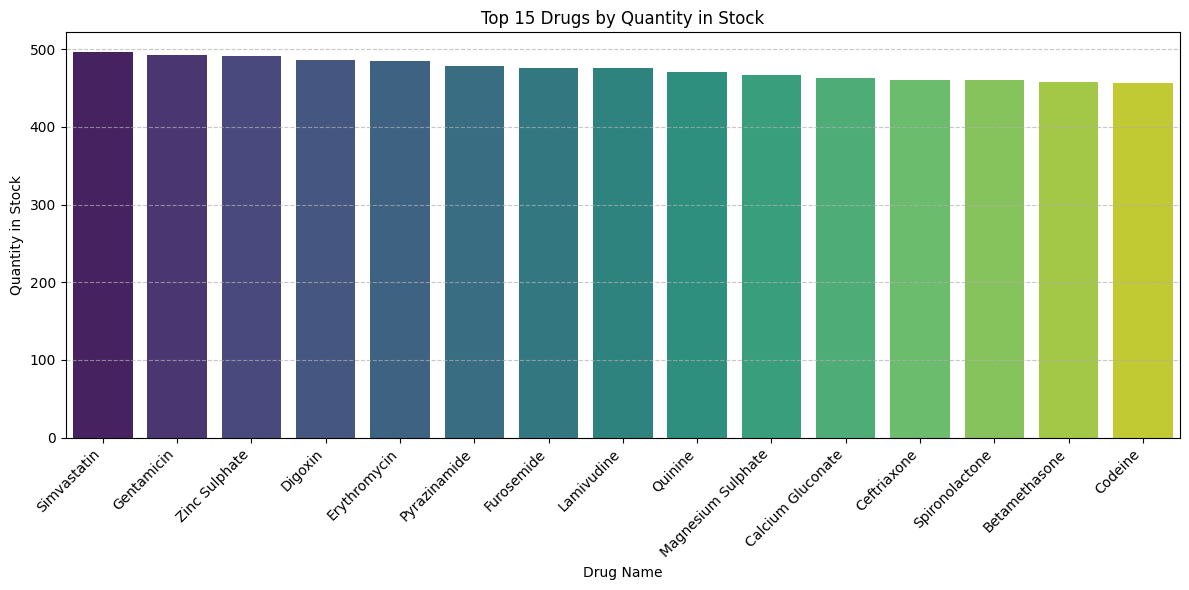

In [25]:
# Call the chart functions using the drug_obj.drugs DataFrame
# Ensure drug_obj is initialized and contains the drug data.

# Bar chart for stock levels
plot_stock_levels(drug_obj.drugs, top_n=15)

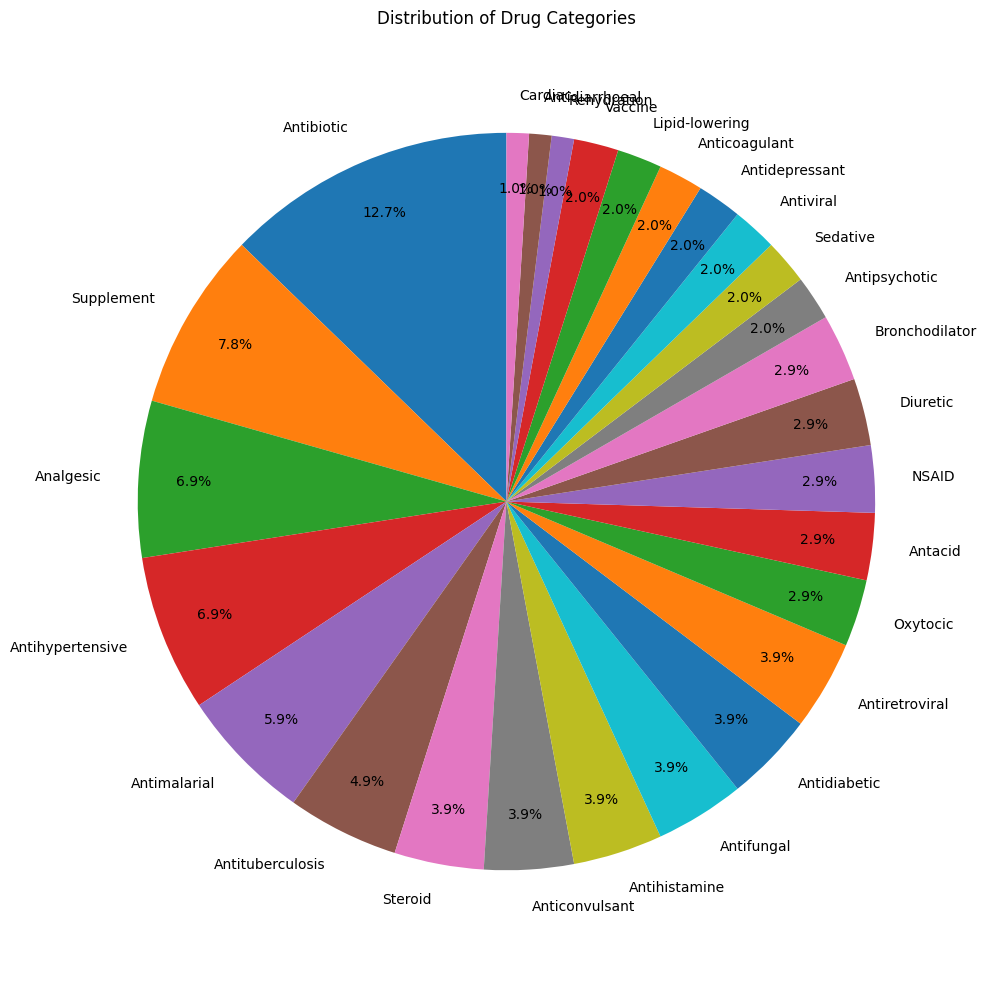

In [26]:
# Pie chart for drug categories
plot_drug_categories(drug_obj.drugs)

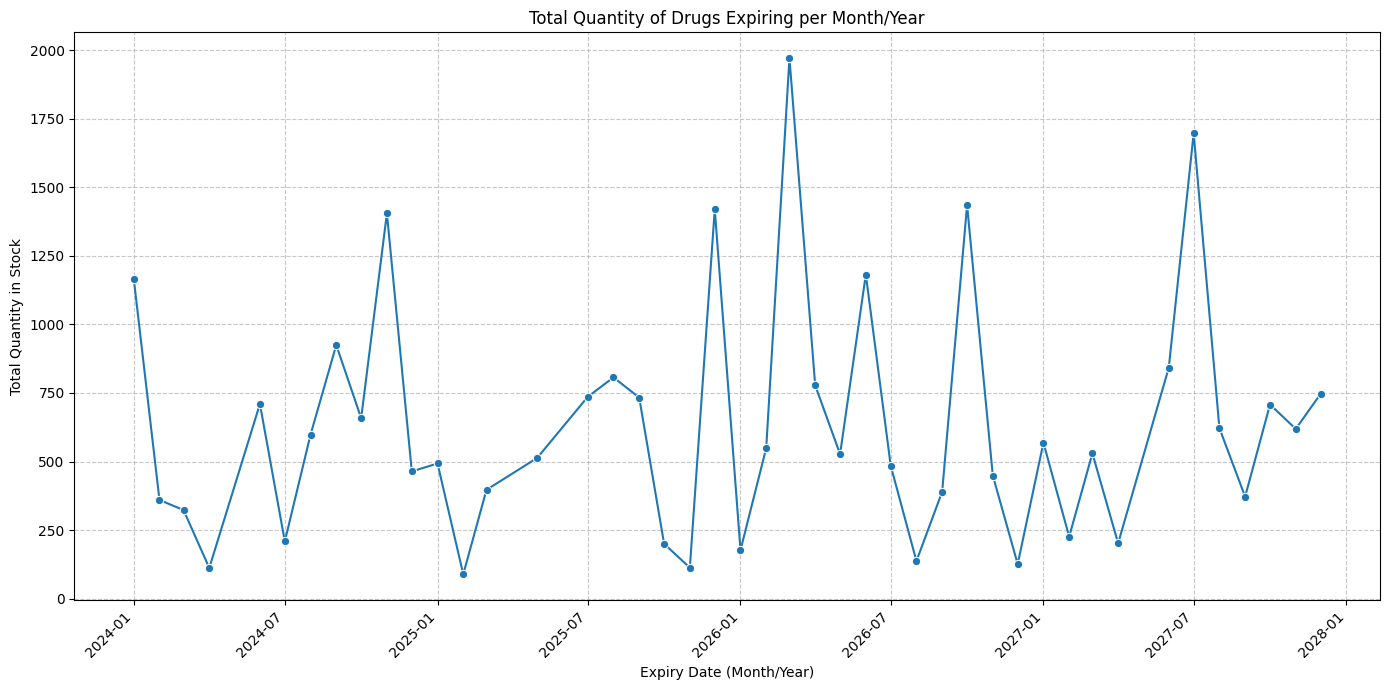

Note: This chart visualizes the total quantity of drugs that will expire each month/year.
The dataset does not contain historical transaction data to show 'stock changes over time' in inventory.


In [27]:
# Line chart for stock by expiry timeline
plot_stock_by_expiry_timeline(drug_obj.drugs)

# **Simple Terminal App**

In [28]:
def main():
    inventory_obj = None # Initialize inventory_obj as None
    print("Welcome to the Drug Inventory Management System!")

    while True:
        print("\n--- Main Menu ---")
        print("1. Load Inventory Data")
        print("2. View Drug Summaries")
        print("3. View Inventory Summaries")
        print("4. Generate Restock Report")
        print("5. Generate Expiry Report")
        print("6. Generate Charts")
        print("7. Exit")

        choice = input("Enter your choice: ").strip()

        if choice == '1':
            print("Loading inventory data...")
            # For now, let's assume `path` and `drug_df` exist from previous cells
            global path, drug_df
            try:
                drug_obj = Drug(path)
                inventory_obj = Inventory(drug_df)
                print("Inventory data loaded successfully!")
            except Exception as e:
                print(f"Error loading inventory: {e}")

        elif choice == '2':
            if inventory_obj:
                print("Viewing Drug Summaries...")
                summary = drug_obj.price_summary()
                print("Most Expensive Drug:", summary["most_expensive"]['drug_name'], "$", summary["most_expensive"]['unit_price_usd'])
                print("Cheapest Drug:", summary["cheapest"]['drug_name'], "$", summary["cheapest"]['unit_price_usd'])
            else:
                print("Please load inventory data first (Option 1).")

        elif choice == '3':
            if inventory_obj:
                print("Viewing Inventory Summaries...")
                summary = inventory_obj.stock_summary()
                print("Most Stocked Drug:", summary["most_stock"]['drug_name'], "Quantity:", summary["most_stock"]['quantity_in_stock'])
                print("Least Stocked Drug:", summary["least_stock"]['drug_name'], "Quantity:", summary["least_stock"]['quantity_in_stock'])
                print("Oldest Expiry Date:", summary["oldest_expiry"]['drug_name'], "Date:", summary["oldest_expiry"]['expiry_date'])
                print("Latest Expiry Date:", summary["latest_expiry"]['drug_name'], "Date:", summary["latest_expiry"]['expiry_date'])
            else:
                print("Please load inventory data first (Option 1).")

        elif choice == '4':
            if inventory_obj:
                print("Generating Restock Report...")
                report = generate_restock_report(inventory_obj)
                print(report)
            else:
                print("Please load inventory data first (Option 1).")

        elif choice == '5':
            if inventory_obj:
                print("Generating Expiry Report...")
                report = generate_expiry_report(inventory_obj)
                print(report)
            else:
                print("Please load inventory data first (Option 1).")

        elif choice == '6':
            if inventory_obj:
                print("Generating Charts...")
                plot_stock_levels(inventory_obj.df, top_n=15)
                plot_drug_categories(inventory_obj.df)
                plot_stock_by_expiry_timeline(inventory_obj.df)
            else:
                print("Please load inventory data first (Option 1).")

        elif choice == '7':
            print("Exiting application. Goodbye!")
            break

        else:
            print("Invalid choice. Please try again.")

if __name__ == '__main__':
    main()

Welcome to the Drug Inventory Management System!

--- Main Menu ---
1. Load Inventory Data
2. View Drug Summaries
3. View Inventory Summaries
4. Generate Restock Report
5. Generate Expiry Report
6. Generate Charts
7. Exit
Enter your choice: 7
Exiting application. Goodbye!


---
## **Summary**

This notebook implements the **Drug Inventory & Expiry Manager** using:

| Requirement | Implementation |
|---|---|
| **Custom Classes (min. 2)** | `Drug` (expiry logic, stock checks) · `Inventory` (manages collection, delegates to functions) |
| **Standalone Functions (min. 3)** | `load_stock()` · `check_expiry()` · `generate_restock_report()` |
| **Pandas — Load & Clean Data** | CSV loaded, missing values handled, types enforced, summary stats printed |
| **Visualisations (min. 3)** | Bar chart · Pie chart · Line chart |

---
*SPARK2026 Mini Capstone — Team 6 `Nigeria-Abuja`*